# Heart Health Dataset: Exploratory Data Analysis (EDA)
## BRFSS 2015 Heart Disease Health Indicators

### Project Overview & Purpose
This notebook performs exploratory data analysis (EDA) on the cleaned BRFSS 2015 Heart Disease Health Indicators dataset (`heart_disease_cleaned.csv`), produced by the data cleaning notebook.

The objective is to understand the distribution of individual variables (univariate analysis) and how those variables relate to heart disease status (bivariate analysis), through visualization and summary statistics. Findings are recorded inline as markdown notes and also logged to a JSON file so the Word documentation generator can pull statistics directly from this notebook's output.

**Structure:**
1. Environment Setup & Data Loading
2. Univariate Analysis (individual variable distributions)
3. Bivariate Analysis (relationships with heart disease)
4. Findings Log Export (JSON)

### Step 1: Environment Setup & Library Imports

**Why this is being done (Logic):**
Before performing any analysis, we must load the required Python libraries. `pandas` handles the tabular dataset, `matplotlib` and `seaborn` produce the charts, `os` manages file paths, and `json` is used to write the findings log that the Word documentation generator reads from.

**How it is being done (Code Explanation):**
- `import pandas as pd`: Imports Pandas for data handling.
- `import matplotlib.pyplot as plt`: Imports the core plotting library.
- `import seaborn as sns`: Imports Seaborn for statistical chart styling.
- `plt.style.use(...)` and `sns.set_palette(...)`: Set a consistent, professional look for every chart in the notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os
import json
import warnings

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# Set display options for clean output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set a consistent, professional chart style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 15,
})

# Colorblind-friendly categorical palette used across all charts
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
sns.set_palette(PALETTE)

# Colors specifically for heart disease comparisons (No vs Yes)
COLOR_NO_DISEASE = '#4C72B0'
COLOR_YES_DISEASE = '#C44E52'

print("Environment successfully setup with Pandas version:", pd.__version__)

Environment successfully setup with Pandas version: 2.2.3


### Step 2: Data Loading & Output Folder Setup

**Why this is being done (Logic):**
We load the cleaned dataset produced by the data cleaning notebook and set up a dedicated `figures` folder to store every chart produced in this notebook, plus a `docs` folder to store the JSON findings log.

**How it is being done (Code Explanation):**
- `pd.read_csv(...)`: Reads the cleaned CSV file into a Pandas DataFrame named `df`.
- `os.makedirs(..., exist_ok=True)`: Creates the `figures` and `docs` output folders if they do not already exist.
- `df.shape`: Confirms the number of rows and columns loaded.

In [ ]:
# Define file paths
data_path = r'D:\UpgradDA\MentorshipProject-2\HeartHealthProject\CLEANED\heart_disease_cleaned.csv'
figures_dir = r'D:\UpgradDA\MentorshipProject-2\HeartHealthProject\FIGURES'
docs_dir = r'D:\UpgradDA\MentorshipProject-2\HeartHealthProject\DOCS'

# Create output folders
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(docs_dir, exist_ok=True)

# Load cleaned dataset
df = pd.read_csv(data_path)

print(f"Cleaned Dataset Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Cleaned Dataset Shape: 229,781 rows and 45 columns


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Sex_Label,Diabetes_Status,General_Health,Age_Category,Education_Level,Income_Bracket,Heart_Disease_or_Attack,High_BP_Label,High_Cholesterol_Label,Cholesterol_Check_5yrs,Smoker_Status,Stroke_History,Physical_Activity,Fruit_Consump_Daily,Veggie_Consump_Daily,Heavy_Alcohol_Consump,Healthcare_Coverage,No_Doctor_Due_To_Cost,Difficulty_Walking,BMI_Category,Age_Group_Broad,Total_Unhealthy_Days,Cardiovascular_Risk_Score
0,0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3,Female,No Diabetes,5 - Poor,60-64,Grade 12 / GED (High School Grad),"$15,000 to < $20,000",No,Yes,Yes,Yes,Yes,No,No,No,Yes,No,Yes,No,Yes,Obese,Older Adults (60+),33,4
1,0,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1,Female,No Diabetes,3 - Good,50-54,College 4+ yrs (College Grad),"Less than $10,000",No,No,No,No,Yes,No,Yes,No,No,No,No,Yes,No,Overweight,Middle-Aged Adults (40-59),0,1
2,0,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8,Female,No Diabetes,5 - Poor,60-64,Grade 12 / GED (High School Grad),"$75,000 or more",No,Yes,Yes,Yes,No,No,No,Yes,No,No,Yes,Yes,Yes,Overweight,Older Adults (60+),60,3
3,0,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6,Female,No Diabetes,2 - Very Good,70-74,Grades 9-11 (Some High School),"$35,000 to < $50,000",No,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,No,No,Overweight,Older Adults (60+),0,1
4,0,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4,Female,No Diabetes,2 - Very Good,70-74,College 1-3 yrs (Some College / Tech),"$20,000 to < $25,000",No,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,No,No,Normal Weight,Older Adults (60+),3,2


### Step 3: Findings Log Initialization

**Why this is being done (Logic):**
To keep the Word documentation in sync with this notebook, every key statistic discovered during EDA is written into a single Python dictionary as we go, then exported to `docs/eda_findings_log.json` at the end of the notebook.

**How it is being done (Code Explanation):**
- `findings_log = {}`: Creates an empty dictionary that will be filled in throughout the notebook.
- Each analysis section below adds its own key (e.g., `'univariate'`, `'bivariate'`) containing the relevant numbers.

In [6]:
# Dictionary that collects every statistic generated in this notebook.
# This is exported to JSON at the end so the Word report can read it directly.
findings_log = {}
findings_log['dataset_shape'] = {'rows': int(df.shape[0]), 'columns': int(df.shape[1])}

## 2. Univariate Analysis

In this section we look at one variable at a time to understand its spread, shape, and any outliers, before looking at relationships between variables.

### Step 4: Distribution of Age, BMI, Mental Health Days, and Physical Health Days

**Why this is being done (Logic):**
`Age`, `BMI`, `MentHlth`, and `PhysHlth` are four of the most important continuous/ordinal health indicators in the dataset. Plotting their distributions shows us the shape of each variable (e.g., skewed vs. symmetric), where most respondents fall, and whether outliers are present.

**How it is being done (Code Explanation):**
- A 2x2 grid of subplots is created with `plt.subplots(2, 2, ...)`.
- `Age_Category` is plotted as a bar chart, since age is stored as 13 ordered bins in this dataset.
- `BMI` is plotted as a histogram, since it is a continuous numeric variable.
- `MentHlth` and `PhysHlth` (days out of the past 30) are plotted as histograms, since most respondents report 0 days and the variables are heavily right-skewed.

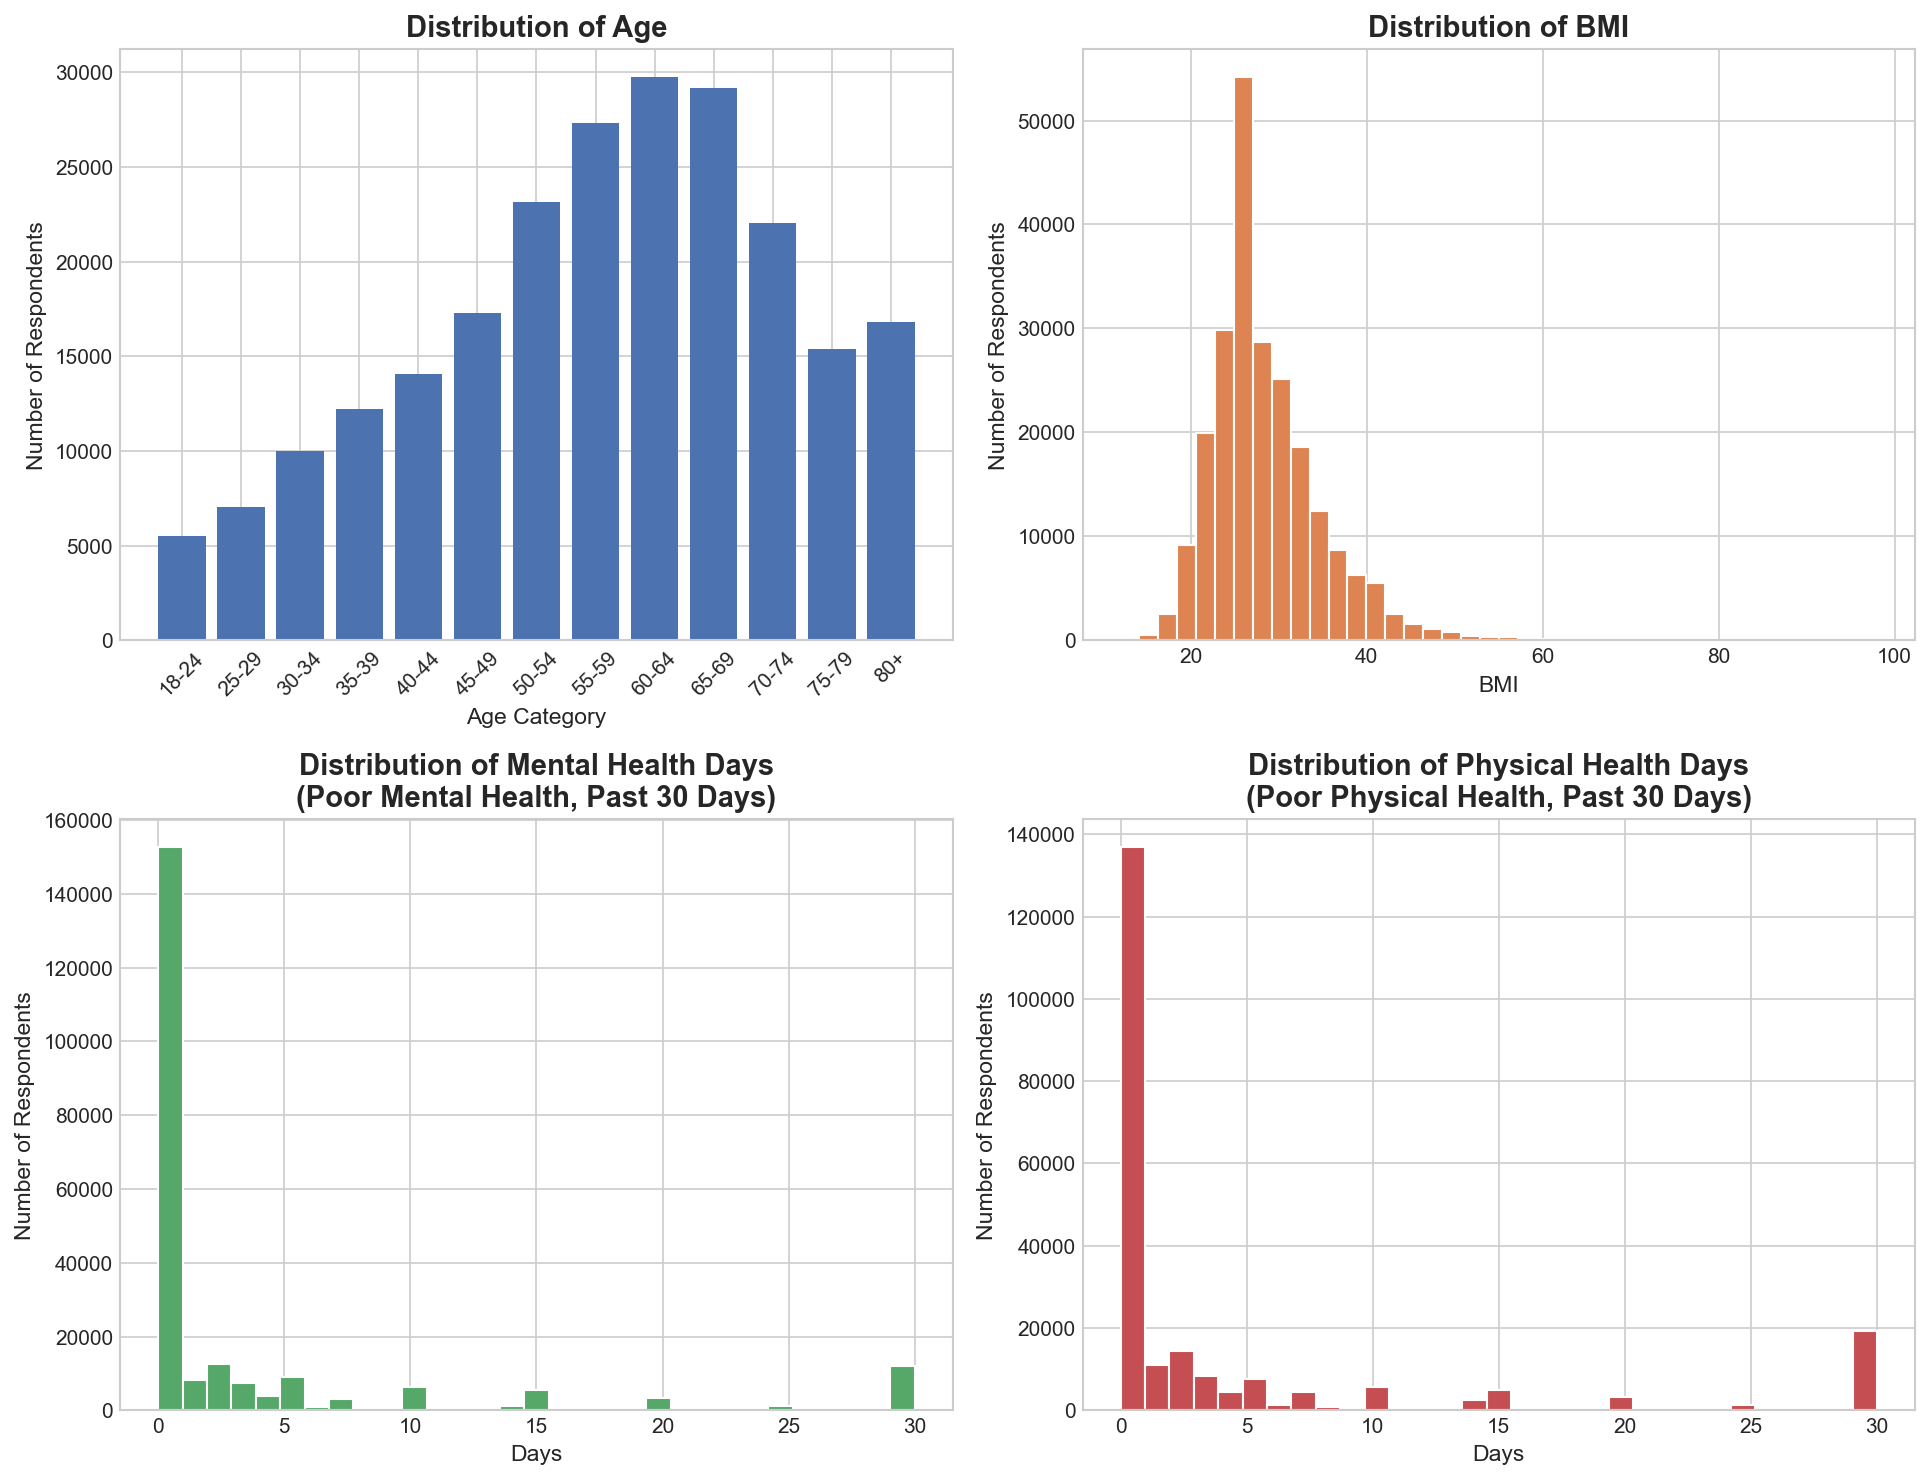

Age category with the most respondents: 60-64
BMI - Mean: 28.69, Median: 27.00, Std Dev: 6.79
Respondents reporting 0 poor mental health days: 66.4%
Respondents reporting 0 poor physical health days: 59.6%


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- Age distribution (ordered bar chart) ---
age_order = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54',
             '55-59', '60-64', '65-69', '70-74', '75-79', '80+']
age_counts = df['Age_Category'].value_counts().reindex(age_order)
axes[0, 0].bar(age_counts.index, age_counts.values, color=PALETTE[0])
axes[0, 0].set_title('Distribution of Age')
axes[0, 0].set_xlabel('Age Category')
axes[0, 0].set_ylabel('Number of Respondents')
axes[0, 0].tick_params(axis='x', rotation=45)

# --- BMI distribution (histogram) ---
axes[0, 1].hist(df['BMI'], bins=40, color=PALETTE[1], edgecolor='white')
axes[0, 1].set_title('Distribution of BMI')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Number of Respondents')

# --- Mental health days distribution (histogram) ---
axes[1, 0].hist(df['MentHlth'], bins=31, color=PALETTE[2], edgecolor='white')
axes[1, 0].set_title('Distribution of Mental Health Days\n(Poor Mental Health, Past 30 Days)')
axes[1, 0].set_xlabel('Days')
axes[1, 0].set_ylabel('Number of Respondents')

# --- Physical health days distribution (histogram) ---
axes[1, 1].hist(df['PhysHlth'], bins=31, color=PALETTE[3], edgecolor='white')
axes[1, 1].set_title('Distribution of Physical Health Days\n(Poor Physical Health, Past 30 Days)')
axes[1, 1].set_xlabel('Days')
axes[1, 1].set_ylabel('Number of Respondents')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig01_age_bmi_menthlth_physhlth_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# Log key univariate statistics
findings_log['univariate'] = {}
findings_log['univariate']['age_mode_category'] = str(age_counts.idxmax())
findings_log['univariate']['bmi_mean'] = round(float(df['BMI'].mean()), 2)
findings_log['univariate']['bmi_median'] = round(float(df['BMI'].median()), 2)
findings_log['univariate']['bmi_std'] = round(float(df['BMI'].std()), 2)
findings_log['univariate']['menthlth_zero_days_pct'] = round(float((df['MentHlth'] == 0).mean() * 100), 2)
findings_log['univariate']['physhlth_zero_days_pct'] = round(float((df['PhysHlth'] == 0).mean() * 100), 2)

print("Age category with the most respondents:", age_counts.idxmax())
print(f"BMI - Mean: {df['BMI'].mean():.2f}, Median: {df['BMI'].median():.2f}, Std Dev: {df['BMI'].std():.2f}")
print(f"Respondents reporting 0 poor mental health days: {(df['MentHlth'] == 0).mean() * 100:.1f}%")
print(f"Respondents reporting 0 poor physical health days: {(df['PhysHlth'] == 0).mean() * 100:.1f}%")

**Finding:** The age distribution skews toward older respondents, with the largest single group in the 60-64 bracket, consistent with BRFSS's telephone-survey sampling. BMI is right-skewed with a median around 27 (overweight range), meaning the typical respondent carries at least some excess weight. Both `MentHlth` and `PhysHlth` are extremely right-skewed: the large majority of respondents report zero poor-health days in the past 30 days, with a long tail of respondents reporting many or all 30 days as unhealthy.

### Step 5: Prevalence of Key Health Conditions

**Why this is being done (Logic):**
`HighBP`, `HighChol`, `Stroke`, `Diabetes`, `Smoker`, and `DiffWalk` are binary or near-binary health condition indicators. Plotting how common each condition is across the full sample gives a baseline understanding of population health before we look at heart disease specifically.

**How it is being done (Code Explanation):**
- A loop builds a summary table of "Yes"/condition-present percentages for each indicator.
- `Diabetes` uses `> 0` to combine "Prediabetes" and "Diabetes" into a single "has some form of diabetes" flag, since the raw column has 3 levels (0/1/2).
- The summary table is plotted as a single horizontal bar chart, sorted from most to least common, which makes conditions easy to compare and rank.

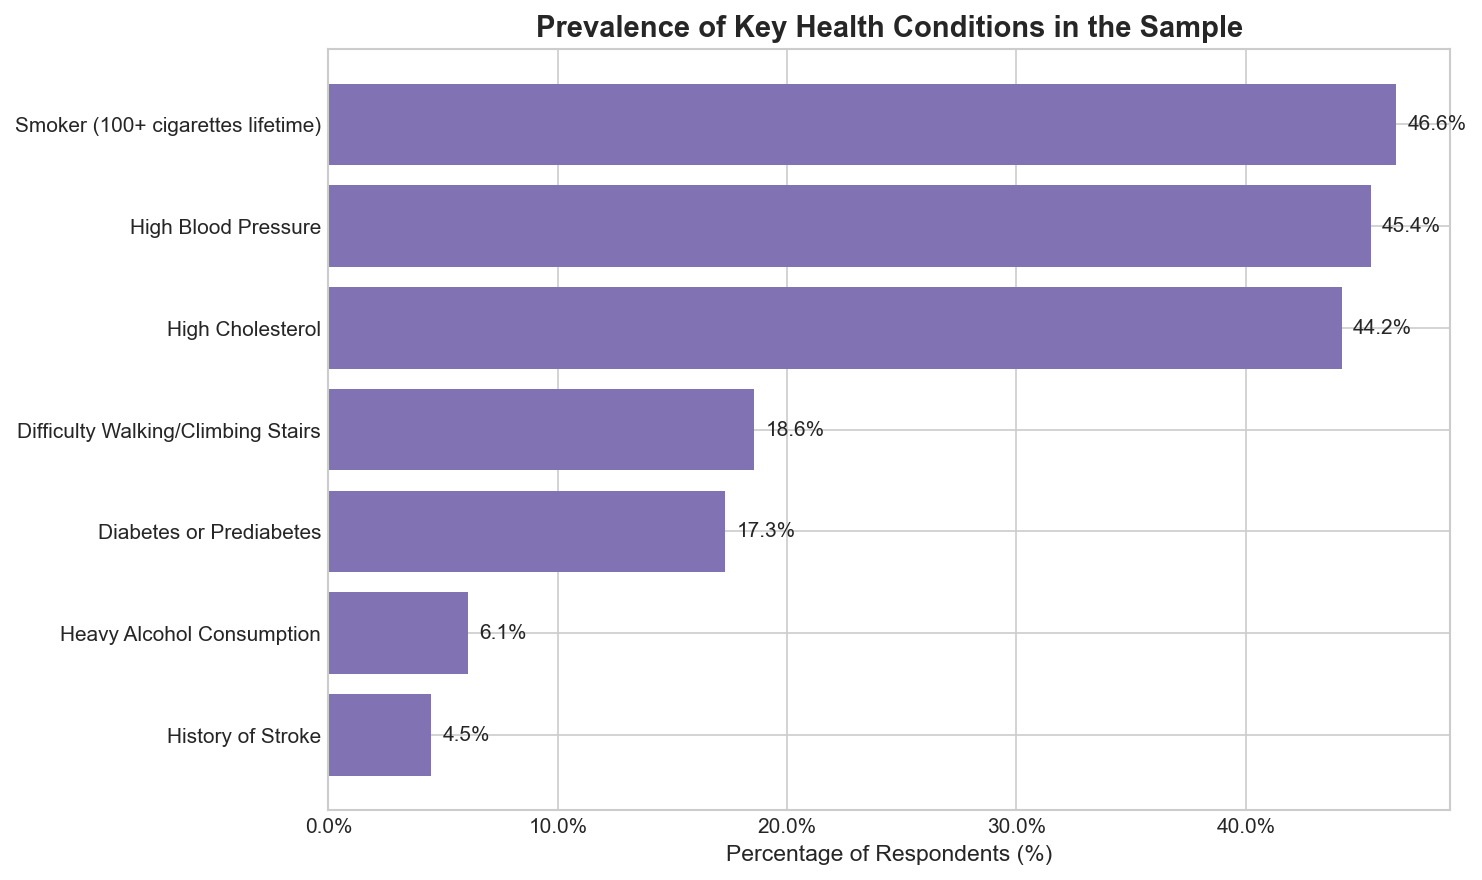

Condition prevalence (% of respondents):
Smoker (100+ cigarettes lifetime)     46.6
High Blood Pressure                   45.4
High Cholesterol                      44.2
Difficulty Walking/Climbing Stairs    18.6
Diabetes or Prediabetes               17.3
Heavy Alcohol Consumption              6.1
History of Stroke                      4.5
dtype: float64


In [8]:
# Binary condition columns and their display labels
condition_cols = {
    'HighBP': 'High Blood Pressure',
    'HighChol': 'High Cholesterol',
    'Smoker': 'Smoker (100+ cigarettes lifetime)',
    'Stroke': 'History of Stroke',
    'DiffWalk': 'Difficulty Walking/Climbing Stairs',
    'HvyAlcoholConsump': 'Heavy Alcohol Consumption',
}

# Build prevalence percentage for each condition using an explicit loop
condition_prevalence = {}
for col, label in condition_cols.items():
    pct_present = (df[col] == 1).mean() * 100
    condition_prevalence[label] = pct_present

# Diabetes is a 3-level column (0 = No, 1 = Prediabetes, 2 = Diabetes); combine 1 and 2
diabetes_any_pct = (df['Diabetes'] > 0).mean() * 100
condition_prevalence['Diabetes or Prediabetes'] = diabetes_any_pct

# Convert to a sorted Series for plotting (highest prevalence at the top)
prevalence_series = pd.Series(condition_prevalence).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prevalence_series.index, prevalence_series.values, color=PALETTE[4])
ax.set_title('Prevalence of Key Health Conditions in the Sample')
ax.set_xlabel('Percentage of Respondents (%)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Add value labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height() / 2, f'{width:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig02_health_condition_prevalence.png'), dpi=150, bbox_inches='tight')
plt.show()

findings_log['univariate']['condition_prevalence_pct'] = {k: round(float(v), 2) for k, v in condition_prevalence.items()}

print("Condition prevalence (% of respondents):")
print(prevalence_series.sort_values(ascending=False).round(1))

**Finding:** High blood pressure and high cholesterol are both present in a substantial share of the sample, making them the most common risk factors observed. Stroke history and heavy alcohol consumption are comparatively rare, while smoking and difficulty walking sit in the middle of the range.

### Step 6: Distribution of Heart Disease (Target Variable)

**Why this is being done (Logic):**
`HeartDiseaseorAttack` is the target variable for this analysis. Before exploring relationships with other variables, we need to understand its own distribution, especially the class balance, since a highly imbalanced target affects how later comparisons should be read.

**How it is being done (Code Explanation):**
- `value_counts()` counts how many respondents fall into each class (0 = No, 1 = Yes).
- A bar chart and a pie chart are placed side by side to show the same information in two complementary formats: the bar chart is easiest for reading exact counts, while the pie chart emphasizes the size of the minority class relative to the whole.

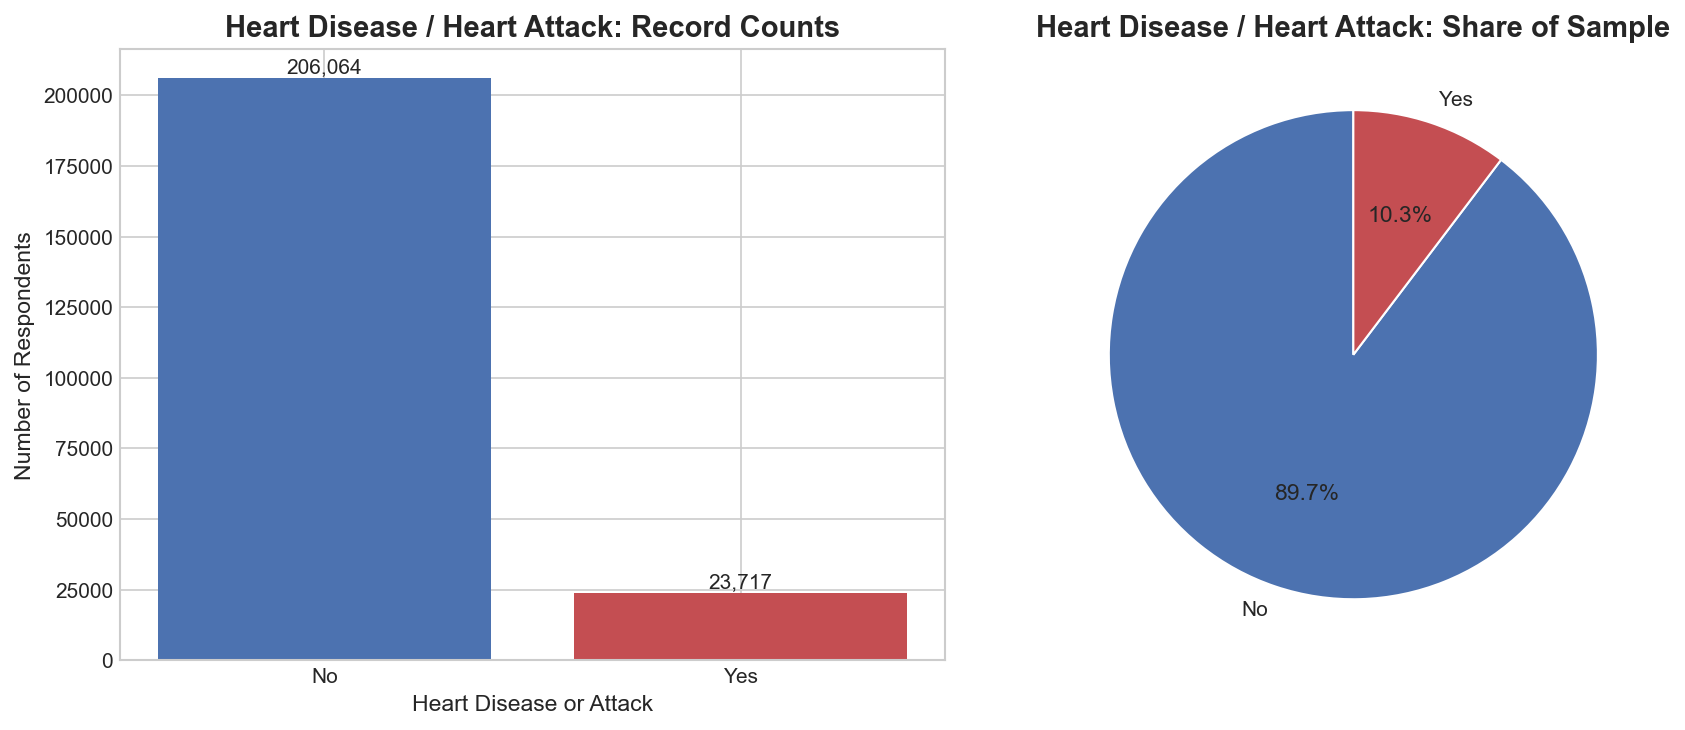

Heart disease / attack distribution:
Heart_Disease_or_Attack
No     206064
Yes     23717
Name: count, dtype: int64
Heart_Disease_or_Attack
No     89.68
Yes    10.32
Name: proportion, dtype: float64


In [9]:
target_counts = df['Heart_Disease_or_Attack'].value_counts()
target_pcts = df['Heart_Disease_or_Attack'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Bar chart ---
bar_colors = [COLOR_NO_DISEASE, COLOR_YES_DISEASE]
axes[0].bar(target_counts.index, target_counts.values, color=bar_colors)
axes[0].set_title('Heart Disease / Heart Attack: Record Counts')
axes[0].set_xlabel('Heart Disease or Attack')
axes[0].set_ylabel('Number of Respondents')
for i, value in enumerate(target_counts.values):
    axes[0].text(i, value + 2000, f'{value:,}', ha='center', fontsize=10)

# --- Pie chart ---
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=bar_colors, startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Heart Disease / Heart Attack: Share of Sample')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig03_heart_disease_target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

findings_log['univariate']['heart_disease_prevalence_pct'] = round(float(target_pcts.get('Yes', 0)), 2)
findings_log['univariate']['heart_disease_counts'] = {str(k): int(v) for k, v in target_counts.items()}

print("Heart disease / attack distribution:")
print(target_counts)
print(target_pcts.round(2))

**Finding:** Heart disease/attack is a minority outcome, present in roughly one in ten respondents. This is a meaningfully imbalanced target, which is worth keeping in mind for any later modeling work: accuracy alone would be a misleading metric, and techniques like class weighting or resampling would likely be needed.

## 3. Bivariate Analysis

In this section we look at how other variables relate to heart disease status, and how continuous variables relate to each other.

### Step 7: High Blood Pressure, High Cholesterol, and BMI vs. Heart Disease

**Why this is being done (Logic):**
`HighBP`, `HighChol`, and `BMI` are three of the most clinically significant heart disease risk factors. Comparing their values between respondents with and without heart disease shows whether these known risk factors actually separate the two groups in this dataset.

**How it is being done (Code Explanation):**
- For `HighBP` and `HighChol`, the percentage of "Yes" respondents is calculated separately within the "No heart disease" group and the "Yes heart disease" group, then plotted as a grouped bar chart.
- For `BMI`, a box plot compares the full distribution (not just the average) of BMI between the two heart disease groups.

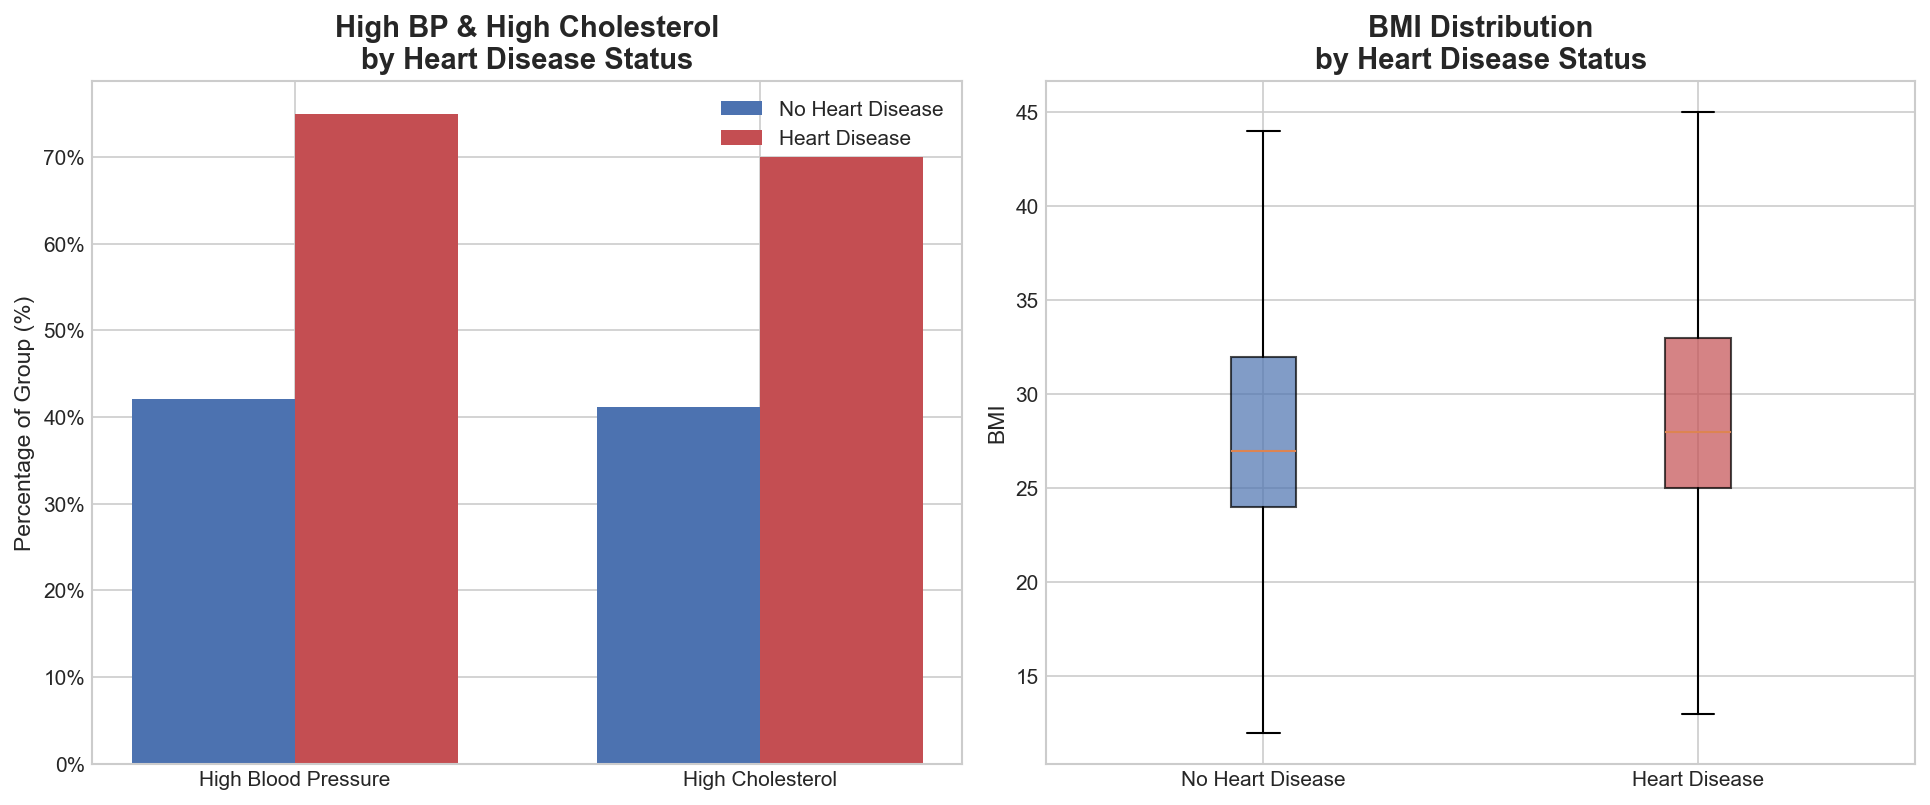

Heart Disease          No   Yes
Condition                      
High Blood Pressure  42.0  75.0
High Cholesterol     41.2  70.0

Median BMI, no heart disease: 27.0
Median BMI, heart disease: 28.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# --- Grouped bar chart: HighBP and HighChol rate within each heart disease group ---
comparison_rows = []
for condition_col, condition_label in [('HighBP', 'High Blood Pressure'), ('HighChol', 'High Cholesterol')]:
    for disease_status in ['No', 'Yes']:
        subset = df[df['Heart_Disease_or_Attack'] == disease_status]
        pct_with_condition = (subset[condition_col] == 1).mean() * 100
        comparison_rows.append({'Condition': condition_label, 'Heart Disease': disease_status, 'Percentage': pct_with_condition})

comparison_df = pd.DataFrame(comparison_rows)
comparison_pivot = comparison_df.pivot(index='Condition', columns='Heart Disease', values='Percentage')

x_positions = np.arange(len(comparison_pivot.index))
bar_width = 0.35
axes[0].bar(x_positions - bar_width / 2, comparison_pivot['No'], width=bar_width, label='No Heart Disease', color=COLOR_NO_DISEASE)
axes[0].bar(x_positions + bar_width / 2, comparison_pivot['Yes'], width=bar_width, label='Heart Disease', color=COLOR_YES_DISEASE)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(comparison_pivot.index)
axes[0].set_ylabel('Percentage of Group (%)')
axes[0].set_title('High BP & High Cholesterol\nby Heart Disease Status')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

# --- Box plot: BMI distribution by heart disease status ---
box_data = [df[df['Heart_Disease_or_Attack'] == 'No']['BMI'], df[df['Heart_Disease_or_Attack'] == 'Yes']['BMI']]
box = axes[1].boxplot(box_data, labels=['No Heart Disease', 'Heart Disease'], patch_artist=True, showfliers=False)
for patch, color in zip(box['boxes'], [COLOR_NO_DISEASE, COLOR_YES_DISEASE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('BMI Distribution\nby Heart Disease Status')
axes[1].set_ylabel('BMI')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig04_highbp_highchol_bmi_vs_heart_disease.png'), dpi=150, bbox_inches='tight')
plt.show()

findings_log['bivariate'] = {}
findings_log['bivariate']['condition_rates_by_disease_status'] = comparison_df.round(2).to_dict(orient='records')
findings_log['bivariate']['bmi_median_no_disease'] = round(float(df[df['Heart_Disease_or_Attack'] == 'No']['BMI'].median()), 2)
findings_log['bivariate']['bmi_median_with_disease'] = round(float(df[df['Heart_Disease_or_Attack'] == 'Yes']['BMI'].median()), 2)

print(comparison_pivot.round(1))
print()
print(f"Median BMI, no heart disease: {df[df['Heart_Disease_or_Attack'] == 'No']['BMI'].median():.1f}")
print(f"Median BMI, heart disease: {df[df['Heart_Disease_or_Attack'] == 'Yes']['BMI'].median():.1f}")

**Finding:** Both high blood pressure and high cholesterol are considerably more common among respondents with heart disease than among those without it, confirming their expected role as risk factors in this dataset. The BMI box plot shows a smaller but consistent shift: the heart disease group has a slightly higher median BMI, though the two distributions overlap substantially, so BMI alone is a weak individual separator between the groups.

### Step 8: Correlation Matrix of Continuous Variables

**Why this is being done (Logic):**
A correlation matrix shows how strongly each pair of continuous/numeric variables moves together, using Pearson correlation. This helps identify which variables are most related to heart disease, and which variables are related to each other (which is useful context for any future modeling to avoid redundant features).

**How it is being done (Code Explanation):**
- A list of continuous/numeric columns of interest is selected, including the target variable `HeartDiseaseorAttack`.
- `df[cols].corr()`: Computes the Pearson correlation coefficient between every pair of selected columns.
- `sns.heatmap(...)`: Visualizes the correlation matrix, with warmer colors indicating stronger positive correlation and cooler colors indicating stronger negative correlation.

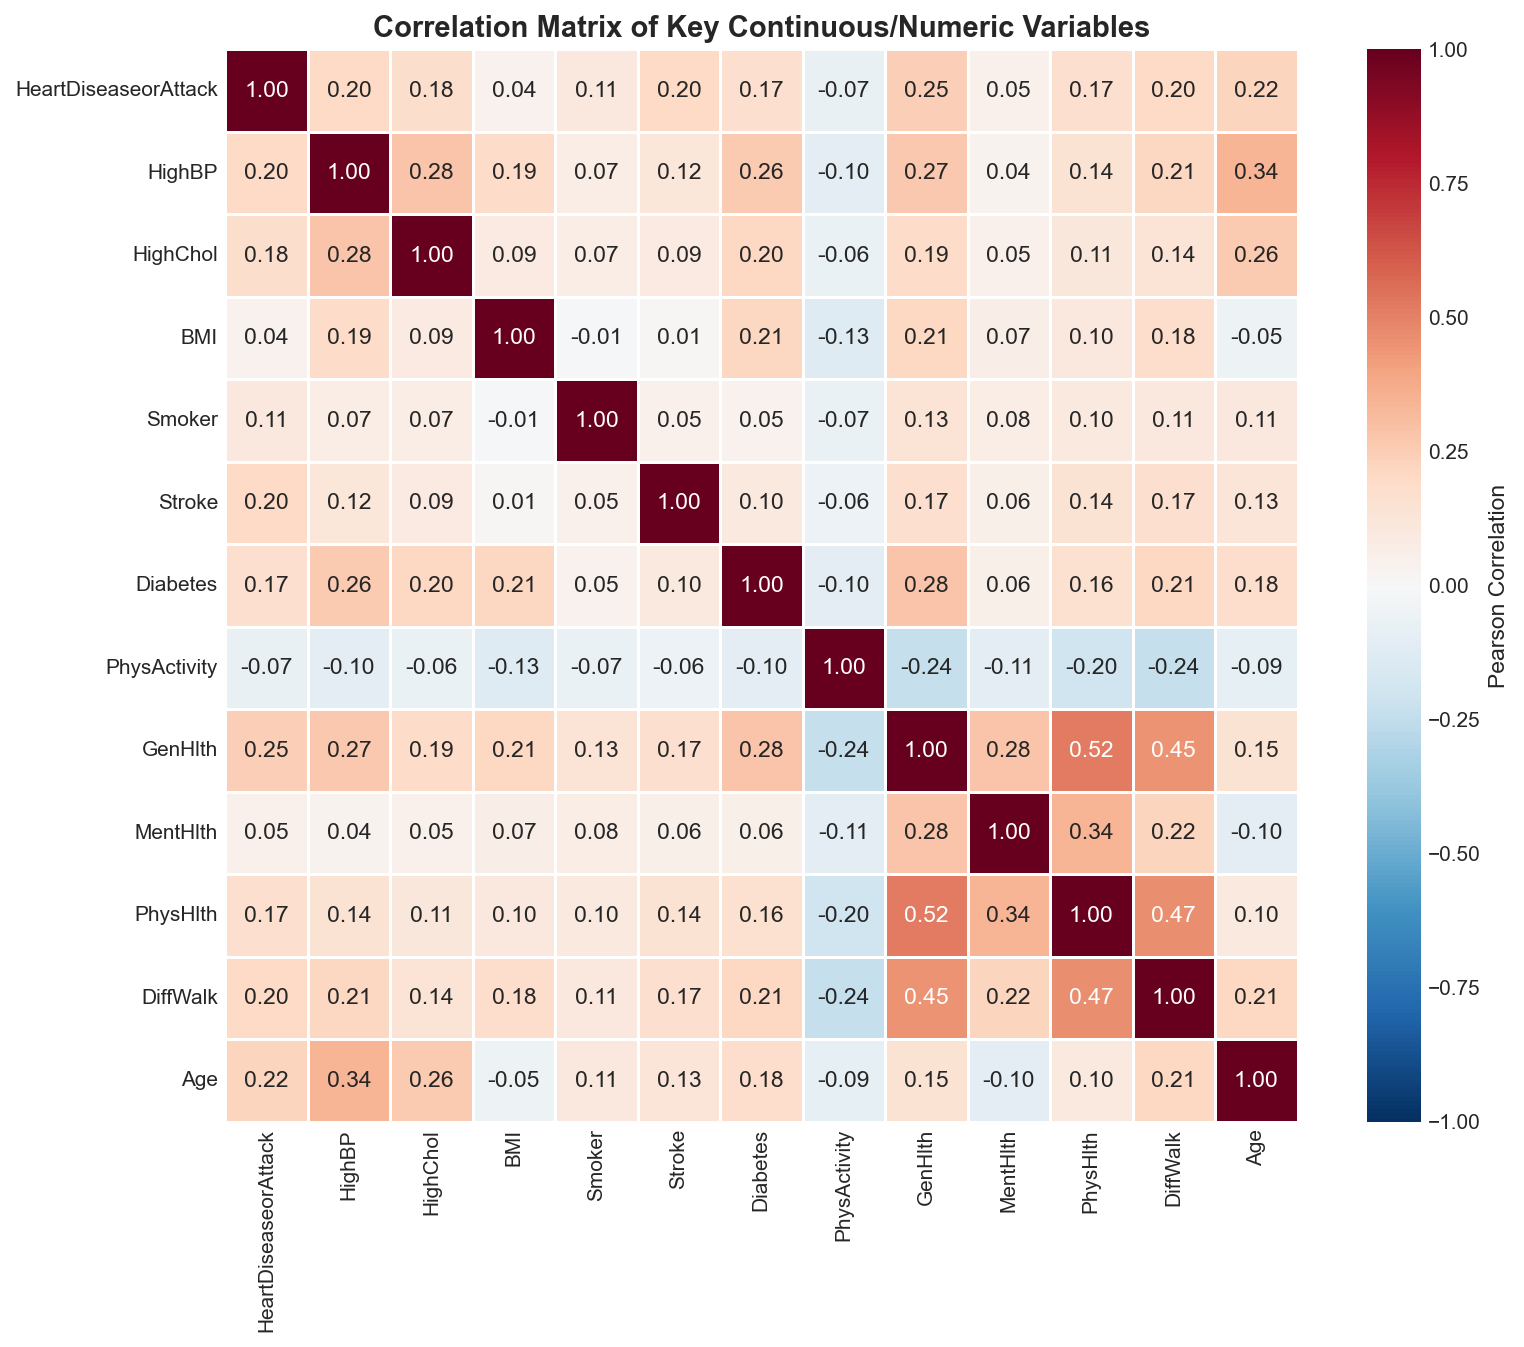

Correlation of each variable with HeartDiseaseorAttack, sorted:
GenHlth         0.246
Age             0.224
DiffWalk        0.203
HighBP          0.201
Stroke          0.199
HighChol        0.176
Diabetes        0.171
PhysHlth        0.170
Smoker          0.105
MentHlth        0.053
BMI             0.040
PhysActivity   -0.073
Name: HeartDiseaseorAttack, dtype: float64


In [11]:
correlation_cols = ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke',
                     'Diabetes', 'PhysActivity', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age']

correlation_matrix = df[correlation_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'}, ax=ax)
ax.set_title('Correlation Matrix of Key Continuous/Numeric Variables')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig05_correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Identify the variables most correlated with heart disease (excluding itself)
heart_disease_correlations = correlation_matrix['HeartDiseaseorAttack'].drop('HeartDiseaseorAttack').sort_values(ascending=False)

findings_log['bivariate']['correlation_with_heart_disease'] = {k: round(float(v), 3) for k, v in heart_disease_correlations.items()}
findings_log['bivariate']['strongest_positive_correlate'] = str(heart_disease_correlations.idxmax())
findings_log['bivariate']['strongest_positive_correlate_value'] = round(float(heart_disease_correlations.max()), 3)

print("Correlation of each variable with HeartDiseaseorAttack, sorted:")
print(heart_disease_correlations.round(3))

**Finding:** `GenHlth` (self-reported general health, where higher numbers mean worse health) shows the strongest correlation with heart disease among the variables tested, followed by `Age`, `DiffWalk`, and `HighBP`. `PhysActivity` shows a negative correlation, consistent with physical activity being protective. No single variable shows a very strong (e.g., above 0.4) correlation on its own, which is typical for health survey data and suggests heart disease risk is driven by a combination of factors rather than any one dominant variable.

### Step 9: Heart Disease Prevalence Across Demographic Groups (Age, Sex, Education)

**Why this is being done (Logic):**
Demographic factors often shape health outcomes in ways that single correlations can miss, especially for categorical variables like `Sex` and `Education_Level`. Plotting heart disease prevalence broken out by age, sex, and education level shows how risk varies across these population subgroups.

**How it is being done (Code Explanation):**
- For each demographic column, the dataset is grouped by that column, and the percentage of respondents with heart disease is calculated within each group using an explicit loop.
- Age is plotted as a line chart (since age categories are ordered), while sex and education are plotted as bar charts (since they are unordered/nominal categories).

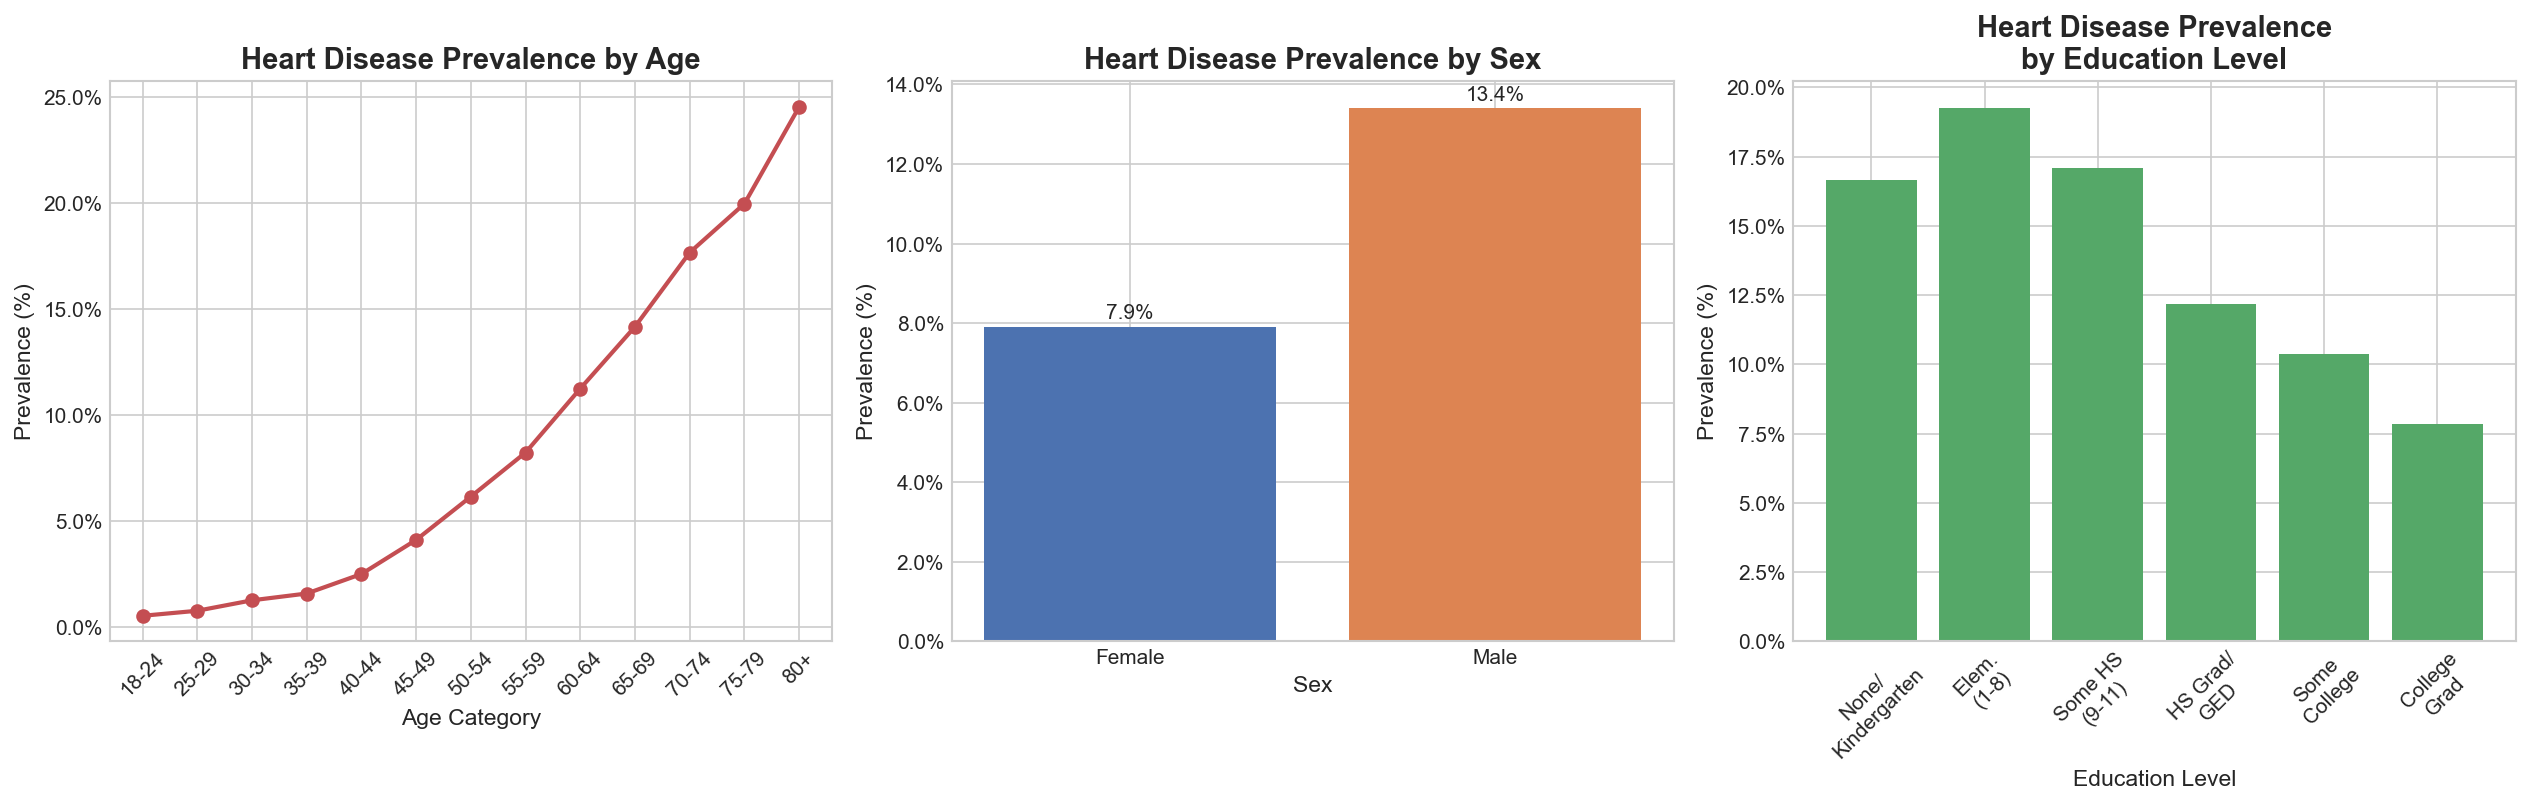

Heart disease prevalence by age category (%):
18-24     0.5
25-29     0.8
30-34     1.3
35-39     1.6
40-44     2.5
45-49     4.1
50-54     6.2
55-59     8.2
60-64    11.3
65-69    14.2
70-74    17.7
75-79    20.0
80+      24.6
dtype: float64

Heart disease prevalence by sex (%):
Female     7.9
Male      13.4
dtype: float64

Heart disease prevalence by education level (%):
Never attended / Kindergarten            16.7
Grades 1-8 (Elementary)                  19.3
Grades 9-11 (Some High School)           17.1
Grade 12 / GED (High School Grad)        12.2
College 1-3 yrs (Some College / Tech)    10.4
College 4+ yrs (College Grad)             7.9
dtype: float64


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# --- Heart disease prevalence by age category (line chart, ordered) ---
age_order = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54',
             '55-59', '60-64', '65-69', '70-74', '75-79', '80+']
age_prevalence = []
for age_group in age_order:
    subset = df[df['Age_Category'] == age_group]
    prevalence_pct = (subset['HeartDiseaseorAttack'] == 1).mean() * 100
    age_prevalence.append(prevalence_pct)

axes[0].plot(age_order, age_prevalence, marker='o', color=COLOR_YES_DISEASE, linewidth=2)
axes[0].set_title('Heart Disease Prevalence by Age')
axes[0].set_xlabel('Age Category')
axes[0].set_ylabel('Prevalence (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

# --- Heart disease prevalence by sex (bar chart) ---
sex_groups = ['Female', 'Male']
sex_prevalence = []
for sex_group in sex_groups:
    subset = df[df['Sex_Label'] == sex_group]
    prevalence_pct = (subset['HeartDiseaseorAttack'] == 1).mean() * 100
    sex_prevalence.append(prevalence_pct)

axes[1].bar(sex_groups, sex_prevalence, color=[PALETTE[0], PALETTE[1]])
axes[1].set_title('Heart Disease Prevalence by Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Prevalence (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
for i, value in enumerate(sex_prevalence):
    axes[1].text(i, value + 0.2, f'{value:.1f}%', ha='center', fontsize=10)

# --- Heart disease prevalence by education level (bar chart) ---
education_order = ['Never attended / Kindergarten', 'Grades 1-8 (Elementary)', 'Grades 9-11 (Some High School)',
                    'Grade 12 / GED (High School Grad)', 'College 1-3 yrs (Some College / Tech)', 'College 4+ yrs (College Grad)']
education_short_labels = ['None/\nKindergarten', 'Elem.\n(1-8)', 'Some HS\n(9-11)', 'HS Grad/\nGED', 'Some\nCollege', 'College\nGrad']
education_prevalence = []
for education_group in education_order:
    subset = df[df['Education_Level'] == education_group]
    prevalence_pct = (subset['HeartDiseaseorAttack'] == 1).mean() * 100
    education_prevalence.append(prevalence_pct)

axes[2].bar(education_short_labels, education_prevalence, color=PALETTE[2])
axes[2].set_title('Heart Disease Prevalence\nby Education Level')
axes[2].set_xlabel('Education Level')
axes[2].set_ylabel('Prevalence (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig06_heart_disease_by_demographics.png'), dpi=150, bbox_inches='tight')
plt.show()

findings_log['bivariate']['prevalence_by_age'] = dict(zip(age_order, [round(float(v), 2) for v in age_prevalence]))
findings_log['bivariate']['prevalence_by_sex'] = dict(zip(sex_groups, [round(float(v), 2) for v in sex_prevalence]))
findings_log['bivariate']['prevalence_by_education'] = dict(zip(education_order, [round(float(v), 2) for v in education_prevalence]))

print("Heart disease prevalence by age category (%):")
print(pd.Series(age_prevalence, index=age_order).round(1))
print()
print("Heart disease prevalence by sex (%):")
print(pd.Series(sex_prevalence, index=sex_groups).round(1))
print()
print("Heart disease prevalence by education level (%):")
print(pd.Series(education_prevalence, index=education_order).round(1))

**Finding:** Heart disease prevalence rises sharply and steadily with age, climbing from under 2% in the youngest group to roughly a quarter of respondents aged 80+, which is the clearest and strongest demographic pattern in the dataset. Male respondents show a noticeably higher prevalence than female respondents. Education level shows an inverse relationship: respondents with less formal education have higher heart disease prevalence than those with a college degree, which is consistent with the well-documented link between socioeconomic status and cardiovascular health.

### Step 10: Comorbidity Count and High-Risk Profile

**Why this is being done (Logic):**
Individual risk factors are informative, but heart disease risk in practice comes from the accumulation of multiple risk factors at once. This step checks for a dose-response relationship by counting how many of six major risk factors (`HighBP`, `HighChol`, `Smoker`, `Stroke`, `Diabetes`, `DiffWalk`) each respondent has, then compares heart disease prevalence across that comorbidity count. It also isolates a "high-risk profile" cohort (older respondents with 3 or more of these risk factors) to see how much their risk differs from the baseline.

**How it is being done (Code Explanation):**
- `comorbidity_count`: A simple row-wise sum of the six binary risk-factor columns (with `Diabetes` converted to 0/1 first).
- The dataset is grouped by `comorbidity_count`, and heart disease prevalence is calculated within each group.
- A high-risk cohort is defined as respondents aged 60+ with a comorbidity count of 3 or more, and its prevalence is compared against the full-sample baseline.

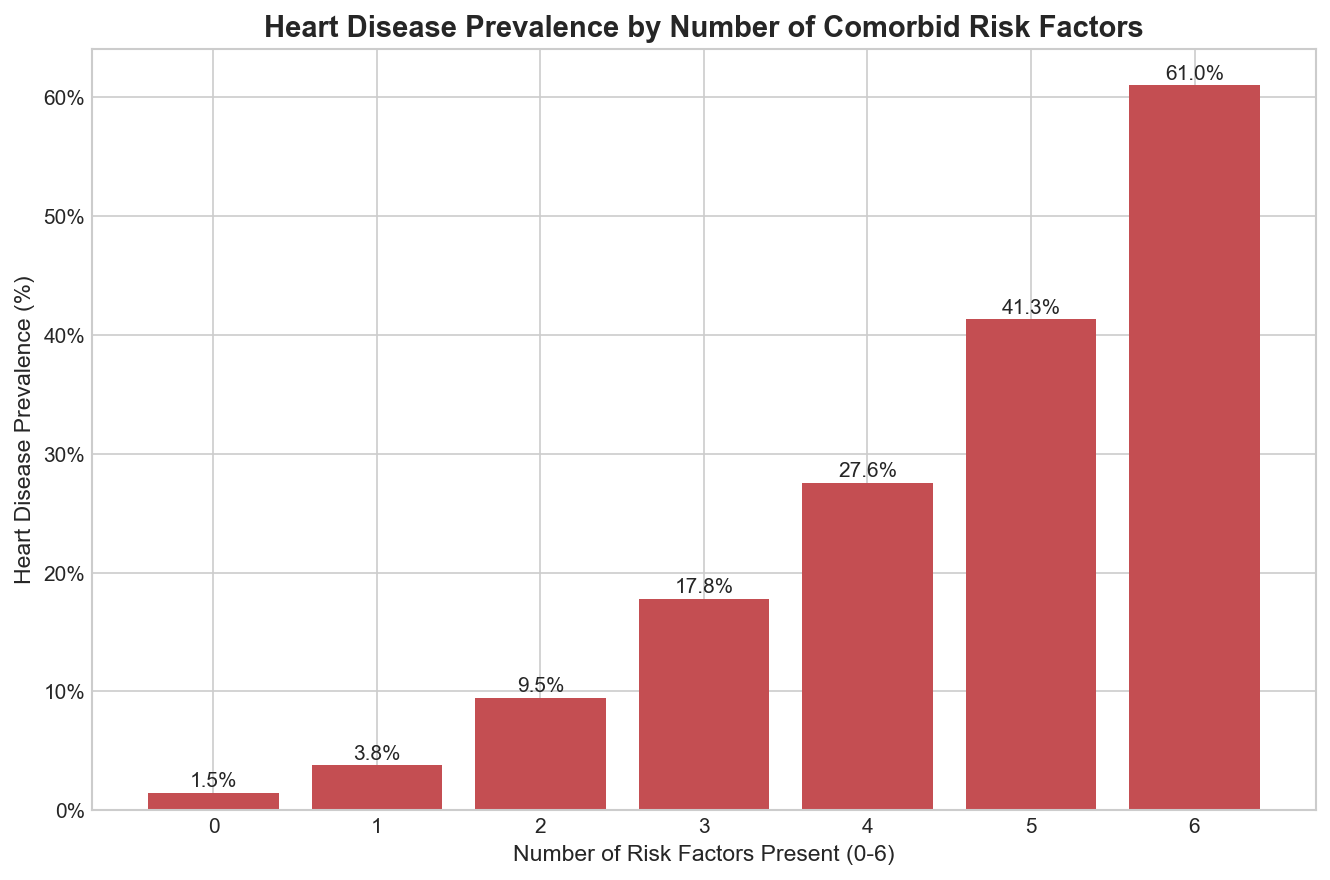

Baseline heart disease prevalence: 10.3%
High-risk cohort (age 60+, 3+ risk factors) size: 45,327
High-risk cohort prevalence: 26.8%
High-risk cohort is 2.6x the baseline rate


In [13]:
# Build a 0-6 comorbidity count using an explicit loop-friendly approach
risk_factor_cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'DiffWalk']
comorbidity_count = df[risk_factor_cols].sum(axis=1) + (df['Diabetes'] > 0).astype(int)
df['Comorbidity_Count'] = comorbidity_count

comorbidity_prevalence = []
comorbidity_levels = sorted(df['Comorbidity_Count'].unique())
for level in comorbidity_levels:
    subset = df[df['Comorbidity_Count'] == level]
    prevalence_pct = (subset['HeartDiseaseorAttack'] == 1).mean() * 100
    comorbidity_prevalence.append(prevalence_pct)

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar([str(level) for level in comorbidity_levels], comorbidity_prevalence, color=PALETTE[3])
ax.set_title('Heart Disease Prevalence by Number of Comorbid Risk Factors')
ax.set_xlabel('Number of Risk Factors Present (0-6)')
ax.set_ylabel('Heart Disease Prevalence (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for i, value in enumerate(comorbidity_prevalence):
    ax.text(i, value + 0.5, f'{value:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig07_prevalence_by_comorbidity_count.png'), dpi=150, bbox_inches='tight')
plt.show()

# High-risk profile cohort: age 60+ with 3 or more comorbid risk factors
baseline_prevalence_pct = (df['HeartDiseaseorAttack'] == 1).mean() * 100
high_risk_subset = df[(df['Age'] >= 9) & (df['Comorbidity_Count'] >= 3)]
high_risk_prevalence_pct = (high_risk_subset['HeartDiseaseorAttack'] == 1).mean() * 100
risk_multiplier = high_risk_prevalence_pct / baseline_prevalence_pct

findings_log['bivariate']['prevalence_by_comorbidity_count'] = dict(zip([str(l) for l in comorbidity_levels], [round(float(v), 2) for v in comorbidity_prevalence]))
findings_log['bivariate']['high_risk_cohort_size'] = int(len(high_risk_subset))
findings_log['bivariate']['high_risk_cohort_prevalence_pct'] = round(float(high_risk_prevalence_pct), 2)
findings_log['bivariate']['baseline_prevalence_pct'] = round(float(baseline_prevalence_pct), 2)
findings_log['bivariate']['high_risk_multiplier'] = round(float(risk_multiplier), 2)

print(f"Baseline heart disease prevalence: {baseline_prevalence_pct:.1f}%")
print(f"High-risk cohort (age 60+, 3+ risk factors) size: {len(high_risk_subset):,}")
print(f"High-risk cohort prevalence: {high_risk_prevalence_pct:.1f}%")
print(f"High-risk cohort is {risk_multiplier:.1f}x the baseline rate")

**Finding:** There is a clear, steady dose-response relationship: heart disease prevalence climbs at almost every additional comorbid risk factor, from under 2% among respondents with zero risk factors to well over a third among respondents carrying five or six. The high-risk profile cohort (age 60+ with three or more risk factors) shows a prevalence several times higher than the baseline rate, confirming that risk factors compound rather than simply add up independently.

## 4. Findings Log Export

**Why this is being done (Logic):**
Exporting all the statistics collected throughout this notebook into a single JSON file keeps the Word documentation generator perfectly in sync with the notebook: any time this notebook is re-run on updated data, the JSON log (and therefore the Word report) automatically reflects the new numbers.

**How it is being done (Code Explanation):**
- `json.dump(findings_log, ...)`: Writes the `findings_log` dictionary to `docs/eda_findings_log.json` with indentation for readability.

In [14]:
output_json_path = os.path.join(docs_dir, 'eda_findings_log.json')

with open(output_json_path, 'w') as f:
    json.dump(findings_log, f, indent=2)

print(f"Findings log successfully exported to: {output_json_path}")
print(f"Top-level keys logged: {list(findings_log.keys())}")

Findings log successfully exported to: D:\UpgradDA\MentorshipProject-2\HeartHealthProject\DOCS\eda_findings_log.json
Top-level keys logged: ['dataset_shape', 'univariate', 'bivariate']


## 5. EDA Summary

**Key takeaways from this notebook:**

1. **Target imbalance:** Heart disease/attack is present in roughly one in ten respondents, an imbalanced target that should inform any future modeling choices (class weighting, resampling, or threshold tuning).
2. **Age is the dominant demographic driver:** Prevalence rises steadily and substantially with age, far more than any other single demographic variable tested.
3. **Known clinical risk factors hold up in this data:** High blood pressure, high cholesterol, poor general health, and difficulty walking are all more common among respondents with heart disease, matching established clinical understanding.
4. **Risk compounds:** Prevalence increases steadily with the number of comorbid risk factors present, and a high-risk demographic/comorbidity profile shows a prevalence several times the baseline rate.
5. **No single dominant predictor:** Correlations between individual variables and heart disease are all modest in isolation, suggesting that risk in this dataset is multi-factorial rather than driven by any one variable.

All charts produced in this notebook are saved to the `figures/` folder, and all statistics are logged to `docs/eda_findings_log.json` for use in the Word documentation.